In [5]:

import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np

## Q1
### Fragment Length Frequency and Rescaling
This question involves analyzing DNA fragment data to:

1. Calculate the normalized frequency distribution of fragment lengths
2. Implement a rescaling algorithm to match a reference distribution

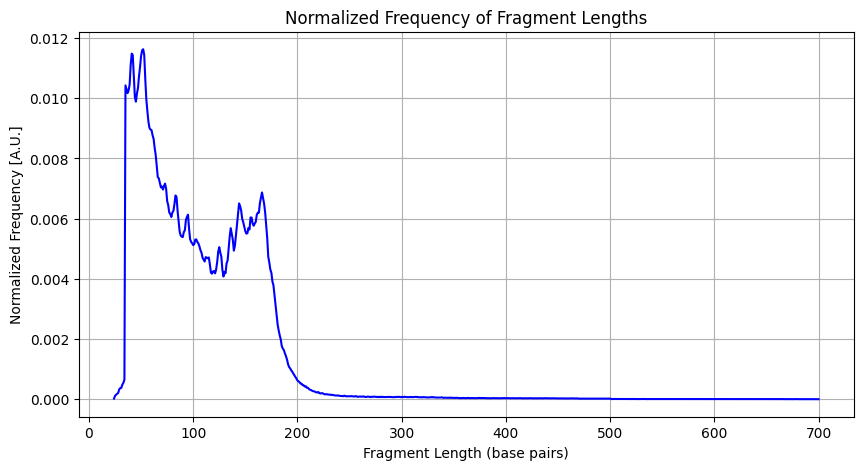

In [6]:


# Initialize list to store fragment lengths
lengths = []

# Read the file and calculate fragment lengths
with open("query.bed", "r") as file:
    for line in file:
        parts = line.strip().split()
        if len(parts) >= 3:
            start = int(parts[1])
            end = int(parts[2])
            length = end - start
            lengths.append(length)
# file.close()

lengths_series = pd.Series(lengths)
frequency = lengths_series.value_counts().sort_index()

# Normalize the fragment lengths by dividing by the total count
total_count = frequency.sum()
normalized_counts = frequency / total_count

plt.figure(figsize=(10, 5))
plt.plot(normalized_counts.index, normalized_counts.values, label="Normalized Frequency", color='b')
plt.xlabel('Fragment Length (base pairs)')
plt.ylabel('Normalized Frequency [A.U.]')
plt.title('Normalized Frequency of Fragment Lengths')
plt.grid(True)
plt.show()


### Processing of rescaling

#### Algorithm Overview:
1. Load reference frequency distribution from 'reference.hist' file
2. Initialize sampling target (target_total = 5,000,000)
3. Iterate through fragment lengths in lengths_series
4. If length already in freq and under target, increment count
5. If length not seen before, initialize count to 1
6. Track total sampled fragments using counter a

In [7]:
ref_freq={}

with open ('reference.hist') as file:
    for line in file:
        line =line.strip().split()
        ref_freq[int(line[0])]=float(line[1])

target_total=5000000
# as subsampling is being done therefore we choose approx 5*10^6 samples out of 13*10^6
freq={}
a=0
# print(lengths_series.describe())

for length in lengths_series:
    if (length in freq) and ref_freq[length]*target_total>freq[length]:
        freq[length]+=1
        a+=1
        
    elif(length not in freq):
        freq[length]=1
        a+=1

# total number of iterms is a
# print(a)



### Combined Graph plotting

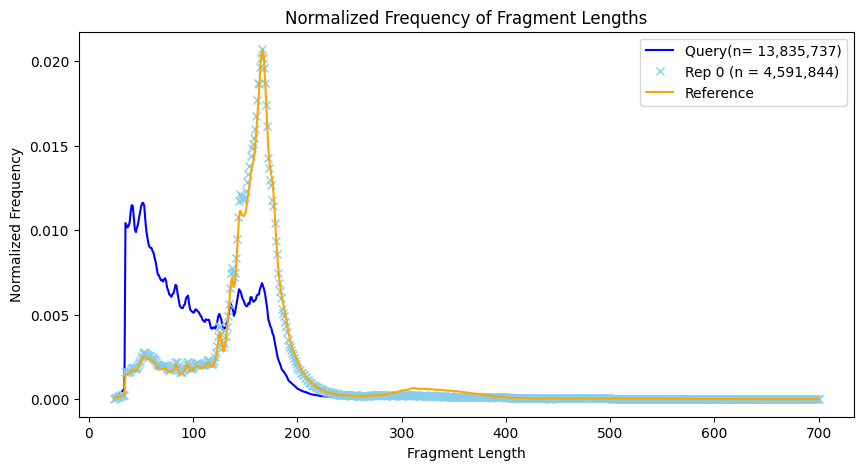

In [8]:
normalized_query = {length: count / a for length, count in freq.items()}

normalized_reference = {length: ref_freq[length] for length in ref_freq}  

common_lengths = set(normalized_query.keys()).intersection(normalized_reference.keys())

common_lengths = sorted(common_lengths)

query_y = [normalized_query[l] for l in common_lengths]
ref_y = [normalized_reference[l] for l in common_lengths]

plt.figure(figsize=(10, 5))
plt.plot(normalized_counts.index, normalized_counts.values, label=f"Query(n= {len(lengths_series):,})", color='b')
plt.plot(common_lengths, query_y, 'x', label=f"Rep 0 (n = {a:,})", color="skyblue")
plt.plot(common_lengths, ref_y, label='Reference', color='orange')
plt.xlabel('Fragment Length')
plt.ylabel('Normalized Frequency')
plt.legend()
plt.title('Normalized Frequency of Fragment Lengths')

plt.show()